In [1]:
import pandas as pd
import numpy as np
print('Pandas is working perfectly fine')

Pandas is working perfectly fine


In [4]:
# Had some problems with the file path, as I was trying to use the CSV file on Codespaces. Importing file directly to the notebook.
import os 
file_name = "healthcare_dataset.csv"

#Learnt how to do a safety 'verification' as an exception handling method.
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print("File read successfully")
else:
    print(f"Error not found {file_name}. in the directory.")

File read successfully


In [5]:
# I use this code to read the csv file and display the first 5 rows of the dataset to notice any immmediate issues with the data. I also use the str.title() method to capitalize the first letter of each word in the 'Name' column for better readability.
df = pd.read_csv("healthcare_dataset.csv")
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,02/02/2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20/08/2019,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,26/08/2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,07/10/2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,09/10/2022,Penicillin,Abnormal


In [6]:
print(df.columns.tolist())


['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [7]:
#Then I use the str.title() method to capitalize the first letter of each word in the 'Name' column for better readability.
df['Name']=  df['Name'].str.title()
# Finally, I round the 'Billing Amount' column to 2 decimal places and rename it to 'Billing Amount ($)' for better clarity.
df = df.rename(columns={'Billing Amount': 'Billing Amount ($)'})
df['Billing Amount ($)'] = df['Billing Amount ($)'].round(2)
df['Billing Amount ($)'] = df['Billing Amount ($)'].dropna()
df['Billing Amount ($)'] = df['Billing Amount ($)'].abs()
df.reset_index(drop=True, inplace=True)
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02/02/2024,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,20/08/2019,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,26/08/2019,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07/10/2022,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09/10/2022,Penicillin,Abnormal


In [8]:
df= df[df['Test Results']!= 'Inconclusive']
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02/02/2024,Paracetamol,Normal
2,Danny Smith,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07/10/2022,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09/10/2022,Penicillin,Abnormal
5,Emily Johnson,36,Male,A+,Asthma,20/12/2023,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,24/12/2023,Ibuprofen,Normal


In [ ]:
#Did this to find out the summary statistics of the dataset, such as the mean, standard deviation, minimum and maximum values, and quartiles. This information can help me understand the distribution of the data and identify any potential outliers or anomalies.
df.describe

In [10]:
df['Medical Condition'].value_counts()
# I noticed that diabetes is the most common medical condition, so I checked the mean billing amount for patients in descending order
df.groupby('Medical Condition')['Billing Amount ($)'].mean().sort_values(ascending=False)
# I then created a new dataframe to display the mean billing amount for each medical condition in descending order, as well as the frequency of each condition via joining.
mean_count = pd.DataFrame(df.groupby('Medical Condition')['Billing Amount ($)'].mean().sort_values(ascending=False)).rename(columns={'Billing Amount ($)':'Mean Billing Amount'}).join(df['Medical Condition'].value_counts()).rename(columns={'count':'Number of Patients'})
print('Average Billing Amount and Number of Patients for each Medical Condition:')
mean_count


Average Billing Amount and Number of Patients for each Medical Condition:


,Mean Billing Amount,Number of Patients
Medical Condition,,
Obesity,25827.610800,6189
Arthritis,25594.835635,6220
Diabetes,25549.508252,6258
Asthma,25536.281985,6156
Hypertension,25315.378437,6154
Cancer,25170.430571,6167


In [11]:
#To look for correlation between blood type and medical condition, I created a new dataframe to display the mean billing amount for each medical condition in descending order, as well as the frequency of each condition via joining.
blood_count=pd.DataFrame(mean_count.join(df.groupby('Medical Condition')['Blood Type'].value_counts().rename('Blood Type Count'), how='right'))
blood_count.head()

Mean Billing Amount  Number of Patients  \
Medical Condition Blood Type                                            
Arthritis         AB-                25594.835635                6220   
                  O+                 25594.835635                6220   
                  B-                 25594.835635                6220   
                  B+                 25594.835635                6220   
                  O-                 25594.835635                6220   

                              Blood Type Count  
Medical Condition Blood Type                    
Arthritis         AB-                      830  
                  O+                       794  
                  B-                       794  
                  B+                       767  
                  O-                       766

In [12]:
#I wanted to remove the Number of Patients and the Mean Billing Amount column from the blood_count dataFrame.
blood_count=blood_count.drop(columns=['Mean Billing Amount']).drop(columns=['Number of Patients'])
blood_count.head(5)

Blood Type Count
Medical Condition Blood Type                  
Arthritis         AB-                      830
                  O+                       794
                  B-                       794
                  B+                       767
                  O-                       766

Hypothesis Testing: Analysing Blood Type against Medical Condition via Chi-Square
Now that I created blood_count, I will use the Chi-Squared test I learnt from school via the scipy library.
This is my hypotheses:
H0 : There is no correlation between the blood type of the patient and their illness.(They are independent)
H1: There is a correlation between the blood type of the patient and their illness.(They are dependent)
I will be using a 1% significance level, though I will compare with other significance levels later on.

In [13]:
# Had to sort a ModuleNotFoundError with scipy.stats in bash , but I managed to run the table!
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Medical Condition'], df['Blood Type'])
print("Contingency Table between Medical Condition and Blood Type:")
print(contingency_table)

Contingency Table between Medical Condition and Blood Type:
Blood Type          A+   A-  AB+  AB-   B+   B-   O+   O-
Medical Condition                                        
Arthritis          746  763  760  830  767  794  794  766
Asthma             735  808  809  762  735  744  790  773
Cancer             809  739  702  830  800  769  736  782
Diabetes           809  817  761  750  792  784  806  739
Hypertension       748  786  823  733  727  790  775  772
Obesity            779  758  767  790  758  795  754  788


In [14]:
# Generated the required statistical values for the contingency table using the chi2_contingency function from scipy.stats.
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print("\nStatistical Values:") #Learnt about newline character \n.
print(f"Chi-Squared Statistic: {chi2_stat:.3f}") # And learnt about 'f' to print variables in a string, and the :._f to round to _ decimal places.
print(f"P-Value: {p_value:.4f}")


Statistical Values:
Chi-Squared Statistic: 48.951
P-Value: 0.0589


Conclusion:
With a P-Value of 0.0589, or approximately 5.9%, it is above the 1% sig. level and is still non-significant at a 5% significance level. 
Thus, I must accept H0: There is indeed independence between the blood type and the patient's likelihood of getting a certain disease in this dataset.

In [15]:
avg_age=pd.DataFrame(df.groupby('Medical Condition')['Age'].mean().sort_values(ascending=False)).rename(columns={'Age':'Average Age'}).dropna()
avg_age['Average Age'] = avg_age['Average Age'].round(2) # Learnt about the round() function 
avg_age
# I realised that the average age of patients with medical conditions is roughly the same, at 51-52 years old.


,Average Age
Medical Condition,
Arthritis,51.64
Hypertension,51.60
Asthma,51.55
Cancer,51.45
Diabetes,51.32
Obesity,51.27


Normal Distribution of Age
I was curious to see how the age of patients would be distributed, since the mean is around 51-52. So, I studied the norm functions in the scipy library to form a normal distribution curve, then used matplotlib along with some np functions I already know to plot on those values to form a static image. Moreover, I wanted to show the mean and standard deviation as stand alone statistics, so I used the f...{._f} step I did in the chi-squared test.


In [16]:
mu = df['Age'].mean()
sigma = df['Age'].std()
df= df[(df['Age'] >=mu - 3*sigma) & (df['Age'] <=mu + 3*sigma)]
 # I used the 3-sigma rule to remove outliers from the Age column, as it is a common method for identifying and removing outliers in a dataset.

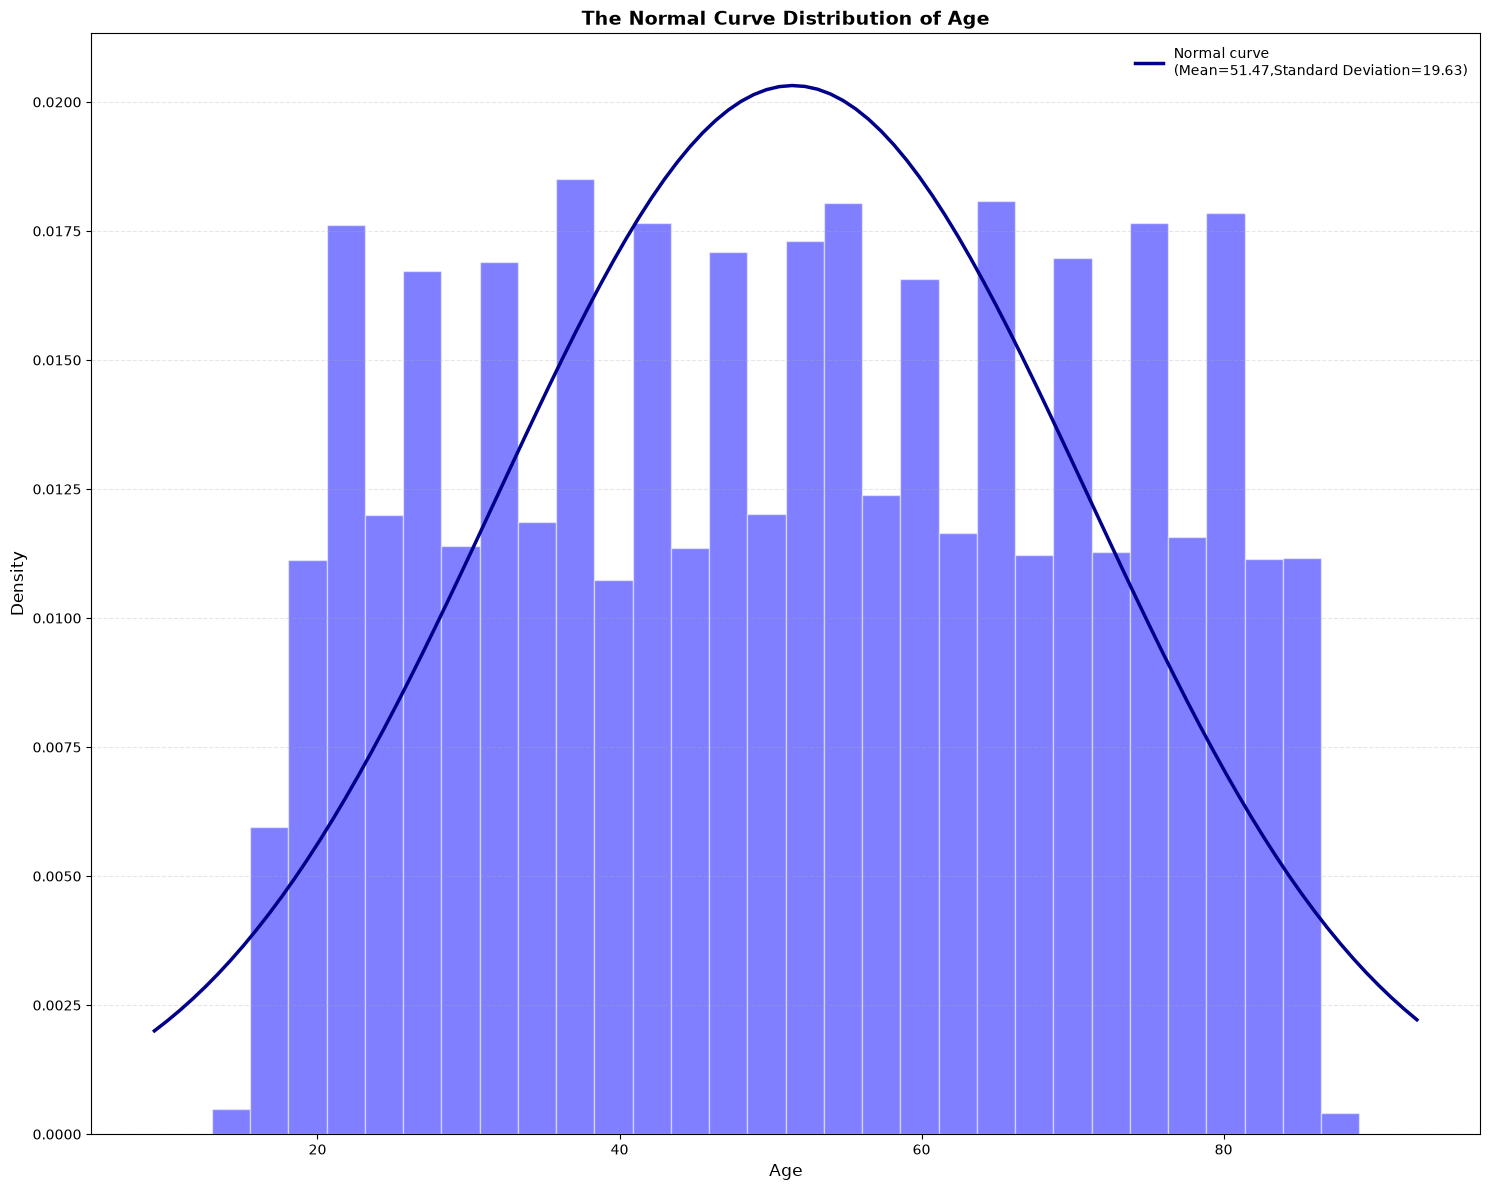

In [62]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm 
%matplotlib inline
plt.figure(figsize=(15, 12))
mu = df['Age'].mean()
sigma = df['Age'].std()
plt.hist(df['Age'], bins=30, density=True, alpha=0.5, color='blue', edgecolor='white')
xmin, xmax = plt.xlim()
x=np.linspace(xmin, xmax, 100)
p= norm.pdf(x,mu, sigma)

plt.plot(x,p,color='darkblue', linewidth=2.5,label=f'Normal curve\n(Mean={mu:.2f},Standard Deviation={sigma:.2f})')
plt.title('The Normal Curve Distribution of Age',fontsize=14,fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--',alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor="none")
plt.tight_layout()
plt.show()

At first, it looked like a perfect bell curve, but I wasn't so sure since patient age data is unlikely to create a perfect normal distribution. 
So I will do a Shapiro-Wilk test to see if the distribution is normal.

In [18]:
from scipy import stats 

data = df['Age']
stat,p_value = stats.shapiro(data)

print(f'Shapiro-Wilk Test Statistic: {stat:.4f}')
print(f'Shapiro-Wilk Test P-Value: {p_value:.4f}')
print('Shapiro-Wilk Test P-Value: {p_value:.4f}')

#I'm setting alpha to 0.05 for the significance level of the Shapiro-Wilk test. If the p-value is less than alpha, we reject the null hypothesis that the data is normally distributed.
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The data is normally distributed.")
else:
    print("Reject the null hypothesis: The data is not normally distributed.")

Shapiro-Wilk Test Statistic: 0.9563
Shapiro-Wilk Test P-Value: 0.0000
Shapiro-Wilk Test P-Value: {p_value:.4f}
Reject the null hypothesis: The data is not normally distributed.


/workspaces/hospital_data_project/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 37144.
  res = hypotest_fun_out(*samples, **kwds)


From the value of the p-value, I assume that the data is too large for the Sharpiro-Wilks test to be accurate. According to the Central Limit Theorem I researched in Further Maths , since N>5000 and it looks like a bell curve, I will assume the distribution of patient's age is normal so that I can use it for future tests.(N=37144)

Anova Test: Does the Hospital patients seek treatment at have a significant difference on the time spent in the hospital?



In [65]:
df['Date of Admission']=pd.to_datetime(df['Date of Admission'],dayfirst=True)
df['Discharge Date'] =pd.to_datetime(df['Discharge Date'],dayfirst=True)
df['Days Spent'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Days Spent']=df['Days Spent'].astype(int).clip(lower=1) 
# I used the clip() method to set a lower limit of 1 for the 'Days Spent' column, as a patient who is admitted and discharged on the same day should be counted as having spent at least 1 day in the hospital.
means_table=df.groupby(df['Medical Condition'])['Days Spent'].mean()
days_total=means_table.to_frame(name='Mean Days Spent').round(0)
print("Mean Days Table: \n", days_total)
days= pd.DataFrame(df['Days Spent']).reset_index(drop=True)
days.head(5)







Mean Days Table: 
                    Mean Days Spent
Medical Condition                 
Arthritis                     16.0
Asthma                        16.0
Cancer                        16.0
Diabetes                      15.0
Hypertension                  15.0
Obesity                       16.0


,Days Spent
0,2
1,15
2,30
3,20
4,4


As the mean days for each disease spent are around 15-16 days, it is unlikely that the p-value would indicate that the mean days are stastically different and any slight difference would be due to chance.
So I would do the ANOVA test based on the most popular hospitals instead.

In [68]:
#I am checking the number and count of unique values in the 'Hospital' Table that had at least 15 patients in the dataset.
freq_hosp = df['Hospital'].value_counts()
freq_hosp = freq_hosp[freq_hosp >= 15] #I picked 15 as it was the mean number of patients per hospital in the dataset. This allows me to focus on hospitals with a significant number of patients, which can provide more reliable insights and reduce noise from hospitals with very few patients.
print(freq_hosp.head())
print(freq_hosp.describe())

Hospital
LLC Smith      31
Smith PLC      30
Smith Group    29
Ltd Smith      29
Smith Ltd      26
Name: count, dtype: int64
count    36.000000
mean     19.166667
std       4.693460
min      15.000000
25%      16.000000
50%      17.000000
75%      20.250000
max      31.000000
Name: count, dtype: float64


In [21]:
freq_hosp=pd.DataFrame(freq_hosp).rename(columns={'count':'Number of Patients'}).sort_values(by='Number of Patients',ascending=True)
freq_hosp = freq_hosp.drop(columns=['Mean Days Spent'], errors='ignore')
freq_hosp = freq_hosp.join(
    df.groupby('Hospital')['Days Spent'].mean().rename('Mean Days Spent')
)
freq_hosp['Mean Days Spent'] = freq_hosp['Mean Days Spent'].round(2)# I was struggling to round the mean days with the {:.f} format specifier, so I used the round() method instead to round the mean days spent to 2 decimal places.
freq_hosp.head()

,Number of Patients,Mean Days Spent
Hospital,,
Jones Ltd,15,15.93
LLC Brown,15,15.53
Group Davis,15,13.27
Brown LLC,15,15.40
Brown Ltd,15,15.47


Upon further inspection, I should do a oneway test instead of a twoway one, as the Hospital patients stay in might have a say in the days spent in the hospital, but the same cannot be said in reverse.
H0: The mean days spent is not statistically different across hospitals, and any difference is due to chance.
H1: The mean days spent is statistally diferent for at least one hospital.

In [22]:
df = df.reset_index(drop=True)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results,Days Spent
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15
2,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
3,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20
4,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,2023-12-24,Ibuprofen,Normal,4


In [23]:
anova_data= df[df['Hospital'].isin(freq_hosp.index)]
# anova_data has a sample size of 690 patients, which is a good sample size for statistical analysis.
anova_data.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results,Days Spent
14,Timothy Burns,67,Female,A-,Asthma,2023-06-28,Krista Smith,Jones LLC,Blue Cross,42.51,115,Elective,2023-07-02,Aspirin,Normal,4
149,Diana Hall,44,Male,B-,Diabetes,2020-01-21,Adriana Morrow,Johnson Group,Blue Cross,26437.77,267,Emergency,2020-01-30,Ibuprofen,Abnormal,9
159,Jeffery Williamson,30,Male,A-,Cancer,2021-08-21,Justin Lowe,PLC Williams,Cigna,2879.46,183,Urgent,2021-08-28,Ibuprofen,Normal,7
240,Donald Kane,49,Female,O+,Diabetes,2021-08-31,Alyssa Walsh,Miller LLC,Cigna,2133.74,189,Urgent,2021-09-05,Ibuprofen,Normal,5
270,Mrs. Jessica Black Md,49,Male,A-,Diabetes,2021-08-09,Christopher Rivera,Williams Group,Medicare,37636.44,385,Elective,2021-09-06,Ibuprofen,Normal,28


ANOVA TESTS FOR HOSPITALS WITH AT LEAST 15 PATIENTS 

In [24]:
from scipy.stats import f_oneway
# I used the f_oneway function from scipy.stats to perform a one-way ANOVA test
unique= anova_data['Hospital'].unique()
groups = [anova_data[anova_data['Hospital'] == hospital]['Days Spent'] for hospital in unique]
print(f"These are the f_statistics and p_values for the ANOVA test for {len(unique)} hospitals with at least 15 patients in the dataset:")
f_statistic, p_value = f_oneway(*groups)
print(f"F-Statistic: {f_statistic:.2f}")
print(f"P-Value: {p_value:.2f}")
if p_value < 0.05:
    print(f'As {p_value:.2f} is less than 0.05, it can be concluded that:')
    print("The null hypothesis is rejected: There is a significant difference in the mean days spent among the hospitals.")
else:
     print(f'As {p_value:.2f} is greater than 0.05, it can be concluded that:')
     print("The null hypothesis cannot be rejected: There is no significant difference in the mean days spent among the hospitals.")

These are the f_statistics and p_values for the ANOVA test for 36 hospitals with at least 15 patients in the dataset:
F-Statistic: 0.92
P-Value: 0.60
As 0.60 is greater than 0.05, it can be concluded that:
The null hypothesis cannot be rejected: There is no significant difference in the mean days spent among the hospitals.


I noticed that the hospitals have similiar names, so I decided to map hospitals together into clusters so I can create any future graphs on it more easily. , then calculate the p-value of the grouping so see if it would be any different.

In [69]:
maps_data=anova_data['Hospital'].value_counts()
maps_data.head()


Hospital
LLC Smith      31
Smith PLC      30
Smith Group    29
Ltd Smith      29
Smith Ltd      26
Name: count, dtype: int64

To create groups , I removed the LLC/Inc/Group/PLC/Ltd to extract the shared company name.

In [26]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols 

# I removed the endings/starts from the Hospital names for easier grouping, then I stored it as a 'Company Group' column.
suffix_regex= r'\b(LLC|Ltd|Group|PLC|Inc)\b'
anova_data['Company Group']=df['Hospital'].str.replace(suffix_regex,'',case= False, regex= True).str.strip()

anova_data['Company Group'].value_counts()

Company Group
Smith       242
Johnson     130
Brown       130
Williams     71
Jones        70
Miller       16
Anderson     16
Davis        15
Name: count, dtype: int64

Here, the data shows that the disproportionate majority of the data are under 'Smith' , and now 8 'companies'(Hospital groups) are now tested under the ANOVA to test for any variance.

ANOVA TEST FOR COMPANY GROUPS

In [27]:
# Making some changes to the original ANOVA code:
unique= anova_data['Company Group'].unique()
groups = [anova_data[anova_data['Company Group'] == hospital]['Days Spent'] for hospital in unique]
print(f"These are the f_statistics and p_values for the ANOVA test for {len(unique)} groups of hospitals with at least 15 patients in the dataset:")
f_statistic, p_value = f_oneway(*groups)
print(f"F-Statistic: {f_statistic:.2f}")
print(f"P-Value: {p_value:.2f}")
if p_value < 0.05:
    print(f'As {p_value:.2f} is less than 0.05, it can be concluded that:')
    print("The null hypothesis is rejected: There is a significant difference in the mean days spent among the hospital groups.")
else:
     print(f'As {p_value:.2f} is greater than 0.05, it can be concluded that:')
     print("The null hypothesis cannot be rejected: There is no significant difference in the mean days spent among the hospital groups.")

These are the f_statistics and p_values for the ANOVA test for 8 groups of hospitals with at least 15 patients in the dataset:
F-Statistic: 0.57
P-Value: 0.78
As 0.78 is greater than 0.05, it can be concluded that:
The null hypothesis cannot be rejected: There is no significant difference in the mean days spent among the hospital groups.


Unsuprisingly  , the data also reflected no significant difference amongst groups above 15 patients. 

In [28]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount ($)', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Days Spent'],
      dtype='str')

In [29]:
#To use for graph
bill_avg = df.groupby('Medical Condition', as_index=False)['Billing Amount ($)'].mean().rename(columns={'Billing Amount ($)': 'Average Billing Amount ($)'})
bill_avg['Average Billing Amount ($)'] = (bill_avg['Average Billing Amount ($)'].round(2))
bill_avg


,Medical Condition,Average Billing Amount ($)
0,Arthritis,25594.84
1,Asthma,25536.28
2,Cancer,25170.43
3,Diabetes,25549.51
4,Hypertension,25315.38
5,Obesity,25827.61


I'll do another Chi-Squared Test with a more realistic hypothesis : 
The Billing Amount is dependent on Admission Type of the Patient.
H0 : There is no correlation
H1 : There is a correlation 

In [ ]:

contingency_table2 = pd.crosstab(df['Days Spent'],df['Medical Condition'])
print("Contingency Table between Medical Condition and Days Spent:")
print(contingency_table2)

In [36]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table2)
print("\nStatistical Values:") 
print(f"Chi-Squared Statistic: {chi2_stat:.3f}") 
print(f"P-Value: {p_value:.4f}")


Statistical Values:
Chi-Squared Statistic: 128.194
P-Value: 0.8385


Conclusion:
With a P-Value of 0.8385, or approximately 84%, it is much higher than the 1% sig. level and is still highly non-significant at multiple significance levels. 
Thus, I must accept H0: There is indeed independence between the days spent and the patient's disease in the dataset.

CONCLUSION:
Although H0 is possible , the p-value is much higher than it should be. For example, someone with Cancer would be more likely to spend longer days than a people with Obesity. Conversely, the p-value of the previous Chi-Sqaured Test would not be that close to 5% in reality. Although a person's blood type might increase their likelihood, there are much more prevalent reasons why they might get the disease(for example, a person's more likely to get Hypertension in this dataset due to their age than their blood type).

HEAT MAP 

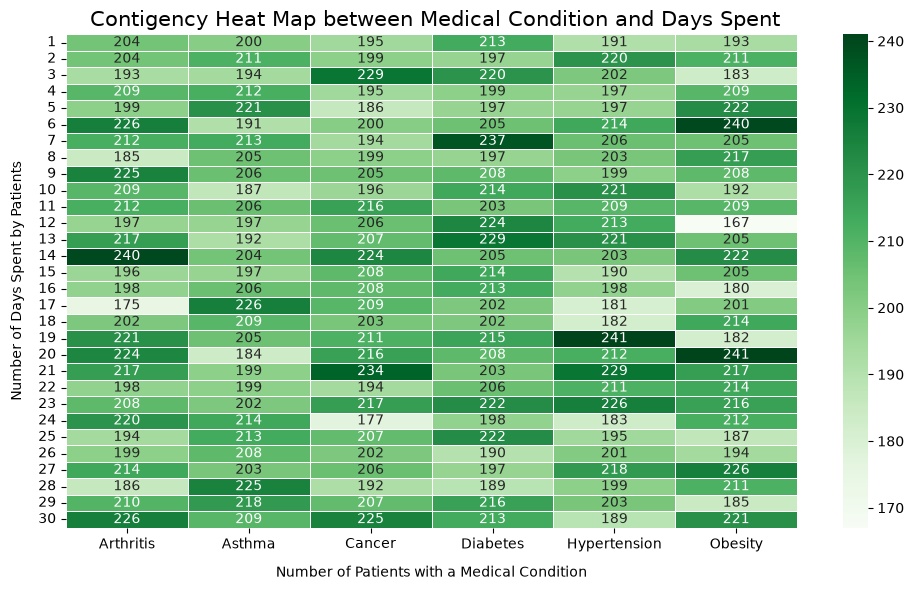

Key: More concentrated colour indicates more patients


In [52]:
import seaborn as sns
# This will set the figure size to 10 by 6
plt.figure(figsize=(10,6))

sns.heatmap(contingency_table2, annot= True, fmt='d',cmap = 'Greens', linewidths=0.5, cbar= True)
plt.title(' Contigency Heat Map between Medical Condition and Days Spent',fontsize=15)
plt.ylabel('Number of Days Spent by Patients', fontsize=10, labelpad=10)
plt.xlabel(' Number of Patients with a Medical Condition ', fontsize=10, labelpad=10)
#Learnt about tight_layout , which prevents the layout from being cut off
plt.tight_layout()
plt.show()

print('Key: More concentrated colour indicates more patients')

The expected result would be darker colours on longer days spent for more long-term diseases such as Cancer, and the inverse for diseases such as Obesity and Diabetes . Instead, the data is nearly prefectly distributed across the diseases, indicating random generation.

In [24]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results,Days Spent
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15
2,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
3,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20
4,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,2023-12-24,Ibuprofen,Normal,4


Billing Amount Predictor
I will use some models to predict the Billing Amount based on most of the dataframe's features that I find relevant to predicting the bill.
By using the scikit-learn library:

In [25]:
#y= df['Billing Amount ($)']
#df_features=['Age', 'Gender', 'Medication', 'Blood Type', 'Hospital', 'Days Spent','Admission Type Sort','Insurance Provider Sort','Medical Condition Sort']
# I tried to use as many features as possible to predict the billing amount, but I had to exclude the 'Test Results', 'Doctor' and 'Names' columns as they are not relevant to the prediction task. I also excluded the 'Billing Amount ($)' column from the features as it is the target variable that I am trying to predict.
#X= df[df_features]

Some of the data is measured in strings, which models like DecisionTreeRegressor can't use
So I am passing some of those through OneHotEncoder:

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
#****Previous Code****#
#preprocessor = ColumnTransformer(
    #transformers=[
        #('cat', OneHotEncoder(handle_unknown='ignore', sparse_output= True), ['Gender', 'Medical Condition', 'Blood Type', 'Hospital', 'Insurance Provider', 'Days Spent'])])


Seperating the data into training and validation datasets to mimic what is done by Data Scientists using train_test_split. 

In [27]:
import sklearn.tree as kit 
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
#train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# This allows me to train the model on one portion of the data and evaluate its performance on another portion, which helps prevent overfitting and provides a more accurate assessment of the model's predictive capabilities.
#I created a pipeline that combines the preprocessor and the decision tree regressor model. The preprocessor handles the categorical features by applying one-hot encoding, while the decision tree regressor is used to predict the billing amount based on the processed features.
# This pipeline allows for a streamlined workflow where data preprocessing and model training are integrated into a single process.
#price_model = Pipeline(steps=[('preprocessor', preprocessor),
                      #('model', DecisionTreeRegressor(max_depth=10, random_state=1))])
# I gave the DecisionTreeRegressor a max_depth of 10 to prevent overfitting and improve the model's generalization to unseen data, as well as to preserve memory.
#  This means that the decision tree will be limited to a maximum depth of 10 levels, which can help reduce the complexity of the model and improve its performance on new data.
#price_model.fit(train_X, train_y)
#val_predictions = price_model.predict(val_X)


In [28]:
#predicted_billings= price_model.predict(X)
#print(f"Mean Absolute Error for validation data: ${mean_absolute_error(val_y, val_predictions):.2f}")
#print(f"Mean Squared Error for validation data: ${mean_squared_error(val_y, val_predictions):.2f}")
#print(f"Mean Absolute Error for all data: ${mean_absolute_error(y, predicted_billings):.2f}")
#print(f"Mean Squared Error for all data: ${mean_squared_error(y, predicted_billings):.2f}")
# Rounded to 2 decimal places as it represents the average error of currency. 

It was interesting to note that the MAE of the training data and the validation data are roughly the same, at about $12 000, though the data is slightly less accurate for the validation data, so I was unsure if the data was overfitted. 
The Mean Sqaured Error also reflects the same pattern.

RandomForest Modelling 

In [29]:
from sklearn.ensemble import RandomForestRegressor 
#price_model2 = Pipeline(steps=[('preprocessor', preprocessor),
 #                     ('model',RandomForestRegressor(max_depth=10, random_state=1))])
#price_model2.fit(train_X, train_y)
#val_forest2 = price_model2.predict(val_X)
#print(f"Mean Absolute Error for validation data(RandomForest): ${mean_absolute_error(val_y, val_forest2):.2f}")
#print(f"Mean Squared Error for validation data(RandomForest): ${mean_squared_error(val_y, val_forest2):.2f}")
#predicted_billings2 = price_model2.predict(X)
#print(f"Mean Absolute Error for all data(RandomForest): ${mean_absolute_error(y, predicted_billings2):.2f}")
#print (f"Mean Squared Error for all data(RandomForest): ${mean_squared_error(y, predicted_billings2):.2f}")


The RandomForest model shows slightly better accuracy for validation data, although the improvement is non-negligible. The total MAE was worse for the RandomForest model.

Overall, 
The MAE for the validation and training data seems too close together for the models to be fitted together. 
From this, I can conclude that the data is underfitted, i.e. the data doesn't understand the nuance of the data.

I can use OrdinalEncoder on the 'Admission Type' first:

In [30]:
admissions= df['Admission Type'].value_counts()
admissions.head()

Admission Type
Elective     12537
Urgent       12410
Emergency    12197
Name: count, dtype: int64

In [31]:
from sklearn.preprocessing import OrdinalEncoder
sort =[['Elective', 'Emergency', 'Urgent']]
encoder = OrdinalEncoder(categories=sort, encoded_missing_value=-1)
df['Admission Type Sort'] = encoder.fit_transform(df[['Admission Type']]).astype(int)
sort_admissions= df['Admission Type Sort']
print(df[['Admission Type', 'Admission Type Sort']].head(5))

  Admission Type  Admission Type Sort
0         Urgent                    2
1      Emergency                    1
2       Elective                    0
3         Urgent                    2
4         Urgent                    2


In [32]:
# I'm doing the same for the insurance provider, as I want to see the mean billing amount for each insurance provider in descending order, as well as the frequency of each provider via joining to determine which insurance providers are associated with higher billing amounts.
insurance_counts = pd.DataFrame((df.groupby('Insurance Provider')['Billing Amount ($)'].mean().sort_values(ascending=False)).round(2))

insurance_counts.head()


,Billing Amount ($)
Insurance Provider,
Medicare,25643.98
Blue Cross,25525.62
Aetna,25475.60
Cigna,25434.98
UnitedHealthcare,25408.44


In [33]:
ins_sort = [['UnitedHealthcare','Cigna','Aetna','Blue Cross','Medicare','Humana','Kaiser Permanente','Anthem','Centene','Molina Healthcare']]
encode2 = OrdinalEncoder(categories=ins_sort, encoded_missing_value=-1)
df['Insurance Provider Sort'] = encode2.fit_transform(df[['Insurance Provider']]).astype(int)
sort_admissions= df['Insurance Provider Sort']
print(df[['Insurance Provider', 'Insurance Provider Sort']].head(5))

  Insurance Provider  Insurance Provider Sort
0         Blue Cross                        3
1              Aetna                        2
2           Medicare                        4
3              Aetna                        2
4   UnitedHealthcare                        0


In [34]:
medical_counts= pd.DataFrame((df.groupby('Medical Condition')['Billing Amount ($)'].mean().sort_values(ascending=False)).round(2))
medical_counts.head()

,Billing Amount ($)
Medical Condition,
Obesity,25825.92
Arthritis,25593.15
Diabetes,25548.48
Asthma,25534.24
Hypertension,25313.35


In [35]:
medi_sort=[['Hypertension', 'Asthma', 'Diabetes', 'Arthritis', 'Cancer', 'Heart Disease', 'Stroke', 'Kidney Disease', 'Liver Disease', 'Obesity', 'Depression', 'Anxiety', 'COPD', 'Osteoporosis', 'Alzheimer\'s Disease', 'Parkinson\'s Disease', 'Multiple Sclerosis', 'Epilepsy', 'HIV/AIDS']]
encode3= [OrdinalEncoder(categories=medi_sort, encoded_missing_value=-1)]
df['Medical Condition Sort'] = encode3[0].fit_transform(df[['Medical Condition']]).astype(int)
sort_medical= df['Medical Condition Sort']
df[['Medical Condition', 'Medical Condition Sort']].head(5)


,Medical Condition,Medical Condition Sort
0,Cancer,4
1,Obesity,9
2,Diabetes,2
3,Cancer,4
4,Asthma,1


In [36]:
test=df.groupby(['Test Results'])['Billing Amount ($)'].mean().sort_values().round(2)
test.head()

Test Results
Normal      25456.65
Abnormal    25538.35
Name: Billing Amount ($), dtype: float64

Test Results costs shows slightly higher bill

In [37]:
test_sort=[['Normal', 'Abnormal']]
encode4= [OrdinalEncoder(categories=test_sort,encoded_missing_value=-1)]
df['Test Results Sort'] = encode4[0].fit_transform(df[['Test Results']]).astype(int)
sort_test=  df['Test Results Sort']
df[['Test Results', 'Test Results Sort']].head(5)



,Test Results,Test Results Sort
0,Normal,0
1,Normal,0
2,Abnormal,1
3,Abnormal,1
4,Normal,0


In [38]:
y= df['Billing Amount ($)']
df_features=['Age', 'Gender', 'Medication', 'Blood Type', 'Hospital', 'Days Spent','Admission Type Sort','Insurance Provider Sort','Medical Condition Sort','Test Results Sort']
# I tried to use as many features as possible to predict the billing amount, but I had to exclude the 'Doctor' and 'Names' columns as they are not relevant to the prediction task.
# I also excluded the 'Billing Amount ($)' column from the features as it is the target variable that I am trying to predict.
X= df[df_features]

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output= True), ['Gender','Blood Type','Hospital', 'Days Spent','Medication'])])

In [40]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
train_X_encoded = preprocessor.fit_transform(train_X)
val_X_encoded = preprocessor.fit_transform(val_X)

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'), ['Gender', 'Blood Type', 'Hospital','Days Spent' ,'Medication'])], remainder='passthrough')

price_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', DecisionTreeRegressor(max_depth=10,max_leaf_nodes=100,random_state=1))])

price_model.fit(train_X, train_y)
val_predictions = price_model.predict(val_X)



In [42]:
predicted_billings= price_model.predict(X)
print(f"Mean Absolute Error for validation data: ${mean_absolute_error(val_y, val_predictions):.2f}")
print(f"Mean Squared Error for validation data: ${mean_squared_error(val_y, val_predictions):.2f}")
print(f"Mean Absolute Error for all data: ${mean_absolute_error(y, predicted_billings):.2f}")
print(f"Mean Squared Error for all data: ${mean_squared_error(y, predicted_billings):.2f}")


Mean Absolute Error for validation data: $12320.59
Mean Squared Error for validation data: $202822436.03
Mean Absolute Error for all data: $12262.16
Mean Squared Error for all data: $201348400.58


In [60]:
price_model2 = Pipeline(steps=[('preprocessor', preprocessor),
                    ('model',RandomForestRegressor(max_depth=10, random_state=1,max_leaf_nodes= 200))])
price_model2.fit(train_X, train_y)
val_forest2 = price_model2.predict(val_X)
print(f"Mean Absolute Error for validation data(RandomForest): ${mean_absolute_error(val_y, val_forest2):.2f}")
print(f"Mean Squared Error for validation data(RandomForest): ${mean_squared_error(val_y, val_forest2):.2f}")
predicted_billings2 = price_model2.predict(X)
print(f"Mean Absolute Error for all data(RandomForest): ${mean_absolute_error(y, predicted_billings2):.2f}")
print (f"Mean Squared Error for all data(RandomForest): ${mean_squared_error(y, predicted_billings2):.2f}")

Mean Absolute Error for validation data(RandomForest): $12297.09
Mean Squared Error for validation data(RandomForest): $201554151.37
Mean Absolute Error for all data(RandomForest): $12293.91
Mean Squared Error for all data(RandomForest): $201285051.65


In [44]:
mean=df['Billing Amount ($)'].mean()
print(f"Mean Billing Amount for all data: ${mean:.2f}")
print(f"MAE Percentage for all data: {mean_absolute_error(y, predicted_billings)/mean*100:.2f}%")

Mean Billing Amount for all data: $25497.62
MAE Percentage for all data: 48.09%


The MAE is half of the Mean Billing Amount, which is expected from a synthetic dataset.

In [45]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results,Days Spent,Admission Type Sort,Insurance Provider Sort,Medical Condition Sort,Test Results Sort
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2,2,3,4,0
1,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15,1,2,9,0
2,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,0,4,2,1
3,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20,2,2,4,1
4,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,2023-12-24,Ibuprofen,Normal,4,2,0,1,0


In [58]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):#
    price_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(max_depth=10,max_leaf_nodes=max_leaf_nodes ,random_state=1))])
    price_model.fit(train_X, train_y)
    preds_val = price_model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)


In [59]:
best_mae= float('inf')
best_tree_size= None
for max_leaf_nodes in [2,20,200,2000]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)

    if my_mae < best_mae:
        best_mae = my_mae
        best_tree_size = max_leaf_nodes 

print(f"Best max_leaf_nodes : {best_tree_size} (MAE : {best_mae})")

Best max_leaf_nodes : 200 (MAE : 12297.09086244481)
